# Lab: Relationships in Space and Time

Florida red tide is caused primarily by high concentrations of the microscopic alga *Karenia brevis*. The organism can produce toxins that harm marine life and cause respiratory irritation near affected shorelines. A bloom does not remain in one fixed place: winds and currents can move and disperse it while its concentration changes.

This lab examines part of the unusually long 2017–2019 Florida red-tide bloom. From June through November 2018, documented bloom concentrations expanded beyond southwest Florida and were detected in the Panhandle and, for part of the period, along the Atlantic coast.

## Learning goals

By the end of this lab, you should be able to:

- prepare and check a temporal feature;
- summarize observations by month;
- create and interpret an interactive time-series plot;
- map observations using exact latitude and longitude coordinates;
- animate spatial observations through time with Plotly Express; and
- distinguish documented sample locations from the complete extent of an environmental event.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The course dataset was prepared from the Florida Fish and Wildlife Conservation Commission's [Historic Harmful Algal Bloom Events 2015–2023 GIS layer](https://gis.myfwc.com/mapping/rest/services/Open_Data/Historic_Harmful_Algal_Bloom_Events_2015___2023/MapServer/12). It contains **7,292 water samples** collected from June 1 through November 30, 2018.

These are sampling records, not a continuous measurement of every part of Florida's coastal water. Sampling included routine monitoring, research, and additional event-response sampling when a bloom was suspected or already known.

# Step 1: Question

> **How did the location and concentration of documented Florida red tide change from June through November 2018?**

**During which month do you predict the greatest share of samples reached bloom concentration?**

Your answer: October 2018. Blooms historically intensify in the early-to-mid fall before water temperatures drop significantly.

**Where around Florida do you predict bloom concentrations will appear by the end of this period?**

Your answer: Starting heavily in Southwest Florida, spreading north into the Panhandle and eventually wrapping around ocean currents to the Atlantic East Coast.

# Step 2: Data

## 1. Import the libraries

Import Pandas and Plotly Express using their conventional aliases.

In [1]:
import pandas as pd
import plotly.express as px

## 2. Read the data

Read `data/florida_red_tide_samples_june_november_2018.csv` into a DataFrame named `red_tide`. Use `parse_dates=["sample_date"]` so Pandas stores the sample date as a datetime rather than text.

In [2]:
red_tide = pd.read_csv("data/florida_red_tide_samples_june_november_2018.csv", parse_dates=["sample_date"])

## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [3]:
# Display first and last 5 rows
display(red_tide.head())
display(red_tide.tail())

# Display data types and missing value counts
print(red_tide.dtypes)
print(red_tide.isnull().sum())

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
0,2018-06-01,Red Reef Park Beach,26.36043,-80.06847,0.5,0.0,Not present/background
1,2018-06-01,Gumbo Limbo Nature Center (Lake Wyman),26.36751,-80.07118,0.5,0.0,Not present/background
2,2018-06-01,Bay Dock (Sarasota Bay),27.33160,-82.57790,0.5,5000.0,Very low
3,2018-06-01,New Pass Dock (Sarasota Bay),27.33375,-82.57938,0.5,1000.0,Not present/background
4,2018-06-01,Dixie Highway Bridge; E of (Indian River),27.85566,-80.49085,1.3,0.0,Not present/background


,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
7287,2018-11-29,Brooks Bridge; W of (Santa Rosa Sound),30.400800,-86.600800,0.1,0.0,Not present/background
7288,2018-11-30,Gasparilla Island; 10 mi W of,26.722583,-82.366933,0.5,20667.0,Low
7289,2018-11-30,Gasparilla Island; 13 mi W of,26.760700,-82.475550,0.5,391020.0,Medium
7290,2018-11-30,Bay Dock (Sarasota Bay),27.331600,-82.577900,0.5,534000.0,Medium
7291,2018-11-30,New Pass Dock (Sarasota Bay),27.333750,-82.579380,0.5,274000.0,Medium


sample_date                       datetime64[us]
location                                     str
latitude                                 float64
longitude                                float64
sample_depth_m                           float64
karenia_brevis_cells_per_liter           float64
abundance_category                           str
dtype: object
sample_date                        0
location                           0
latitude                           0
longitude                          0
sample_depth_m                    33
karenia_brevis_cells_per_liter     0
abundance_category                 0
dtype: int64


### Data dictionary

| Feature | Meaning |
| --- | --- |
| `sample_date` | Calendar date on which the water sample was collected |
| `location` | Description or name of the sampling location |
| `latitude` | Sample latitude in decimal degrees north |
| `longitude` | Sample longitude in decimal degrees; values west of the prime meridian are negative |
| `sample_depth_m` | Sampling depth in meters |
| `karenia_brevis_cells_per_liter` | Number of *Karenia brevis* cells measured per liter of water |
| `abundance_category` | FWC concentration category calculated from the cell count |

The FWC categories are:

- **Not present/background:** 0–1,000 cells per liter
- **Very low:** over 1,000–10,000
- **Low:** over 10,000–100,000
- **Medium:** over 100,000–1,000,000
- **High:** over 1,000,000

For this lab, a sample is at **bloom concentration** when it contains at least 100,000 cells per liter.

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `sample_date` | Temporal | datetime64[us] | 0 |
| `location` | Categorical | object | 0 |
| `latitude` | Spatial | float64 | 0 |
| `longitude` | Spatial | float64 | 0 |
| `sample_depth_m` |Numeric  | float64 | 33 |
| `karenia_brevis_cells_per_liter` | Numeric | float64 | 0 |
| `abundance_category` | Categorical | object | 0 |

**What does one row represent?**

Your answer: A single water sample collected at a specific location on a specific date to test for the concentration of Karenia brevis.

**Why can the same location appear in more than one row?**

Your answer: Researchers and officials routinely return to the same testing sites over time to track changes, or they might take multiple samples at different depths on the same day.

# Step 3: Operation

## 4. Sort the samples by date

Sort `red_tide` by `sample_date`. Use `inplace=True` to modify the existing DataFrame rather than creating another one.

In [4]:
red_tide.sort_values("sample_date", inplace=True)

## 5. Create monthly time features

Create `month` by using datetime methods to convert each `sample_date` to a monthly period and then back to a timestamp. The resulting timestamp represents the first day of its month and can be sorted chronologically.

Then create `month_label` with `.dt.strftime("%B %Y")`. This creates readable labels such as `June 2018` for the animation.

In [5]:
red_tide["month"] = red_tide["sample_date"].dt.to_period("M").dt.to_timestamp()
red_tide["month_label"] = red_tide["sample_date"].dt.strftime("%B %Y")

## 6. Identify samples at bloom concentration

Create a Boolean feature named `bloom_level` that is `True` when `karenia_brevis_cells_per_liter` is at least 100,000 and `False` otherwise.

In [6]:
red_tide["bloom_level"] = red_tide["karenia_brevis_cells_per_liter"] >= 100000

## 7. Create a monthly summary

Group the records by `month` and use `.agg()` to calculate:

- `total_samples`: the number of cell-count records in each month; and
- `bloom_samples`: the sum of `bloom_level` in each month.

Summing works because Pandas evaluates `True` as 1 and `False` as 0. Use `.reset_index()` to return `month` to a regular column.

Then calculate `percent_bloom` as the number of bloom samples divided by the total number of samples, multiplied by 100. Display `monthly_summary`.

In [7]:
monthly_summary = red_tide.groupby("month").agg(
    total_samples=("karenia_brevis_cells_per_liter", "count"),
    bloom_samples=("bloom_level", "sum")
).reset_index()

monthly_summary["percent_bloom"] = (monthly_summary["bloom_samples"] / monthly_summary["total_samples"]) * 100
display(monthly_summary)

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


## 8. Prepare the map data

To keep the spatial figures readable, create `map_data` containing samples with more than 10,000 cells per liter. Use `.copy()` because `map_data` will be a separate DataFrame used for the figures.

Create `month_order` from the unique `month_label` values. Because the rows were sorted first, the labels will be in chronological order. Also create `abundance_order` containing `Low`, `Medium`, and `High` in that order.

Samples at or below 10,000 cells per liter remain in `red_tide` and in the monthly summary; they are omitted only from the maps.

In [8]:
map_data = red_tide[red_tide["karenia_brevis_cells_per_liter"] > 10000].copy()

# The rows were already sorted, so unique() preserves the chronological order
month_order = red_tide["month_label"].unique()
abundance_order = ["Low", "Medium", "High"]

# Step 4: Check

## 9. Check the prepared data

Display:

- the number of rows;
- the earliest and latest dates;
- the number of unique months;
- missing-value counts for the date, coordinates, cell count, and depth; and
- descriptive statistics for latitude, longitude, depth, and cell count.

In [9]:
print(f"Number of rows: {len(red_tide)}")
print(f"Earliest date: {red_tide['sample_date'].min()}")
print(f"Latest date: {red_tide['sample_date'].max()}")
print(f"Number of unique months: {red_tide['month'].nunique()}\n")

print("Missing Values:")
print(red_tide[["sample_date", "latitude", "longitude", "karenia_brevis_cells_per_liter", "sample_depth_m"]].isnull().sum(), "\n")

print("Descriptive Statistics:")
display(red_tide[["latitude", "longitude", "sample_depth_m", "karenia_brevis_cells_per_liter"]].describe())

Number of rows: 7292
Earliest date: 2018-06-01 00:00:00
Latest date: 2018-11-30 00:00:00
Number of unique months: 6

Missing Values:
sample_date                        0
latitude                           0
longitude                          0
karenia_brevis_cells_per_liter     0
sample_depth_m                    33
dtype: int64 

Descriptive Statistics:


,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter
count,7292.000000,7292.000000,7259.000000,7.292000e+03
mean,27.428306,-82.253707,1.326353,5.472636e+05
std,1.297599,1.452258,4.368422,3.276337e+06
min,24.455000,-87.325914,0.000000,0.000000e+00
25%,26.576700,-82.683950,0.500000,0.000000e+00
50%,27.308970,-82.337920,0.500000,0.000000e+00
75%,28.047500,-81.408525,0.500000,3.066700e+04
max,30.701200,-79.948800,71.000000,9.000000e+07


**Why do the 33 missing depth values not require us to remove those records from this analysis?**

Your answer: We are exclusively analyzing geographical location (latitude/longitude) and time. Since depth is not a variable in our monthly summaries or our spatial maps, the missing depth values do not impact our calculations.

## 10. Check the aggregation

Display `monthly_summary`, then compare the sum of `total_samples` with the number of rows in `red_tide`. Compare the sum of `bloom_samples` with the sum of `bloom_level` in the original DataFrame.

In [10]:
display(monthly_summary)

print("--- Aggregation Check ---")
print(f"Total samples in summary matches original data: {monthly_summary['total_samples'].sum() == len(red_tide)}")
print(f"Total bloom samples in summary matches original data: {monthly_summary['bloom_samples'].sum() == red_tide['bloom_level'].sum()}")

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


--- Aggregation Check ---
Total samples in summary matches original data: True
Total bloom samples in summary matches original data: True


**What kind of preparation error could be revealed if either pair of totals did not match?**

Your answer: A mismatch would indicate that rows were unintentionally dropped or that missing values in the grouping feature caused Pandas to exclude those records from the total sum.

# Step 5: Evidence

## 11. Plot the monthly percentage at bloom concentration

Use `px.line()` with `monthly_summary` to plot `month` against `percent_bloom`. Show markers and add a question-focused title and readable axis labels.

In [11]:
fig = px.line(
    monthly_summary,
    x="month",
    y="percent_bloom",
    markers=True,
    title="Percentage of Documented Samples at Bloom Concentration (June - Nov 2018)",
    labels={
        "month": "Month",
        "percent_bloom": "Percentage at Bloom Level (%)"
    }
)
fig.show()

**During which month was the percentage of samples at bloom concentration highest?**

Your answer: August 2018

**What temporal pattern do you observe from June through November?**

Your answer: The severity peaked in late summer (August) before dropping in the early fall and then experiencing a secondary spike in November.

## 12. Map the documented sample locations

Create a static `px.scatter_map()` using `map_data`.

- Use the exact `latitude` and `longitude` features.
- Map `abundance_category` to color.
- Use `location` as the hover name.
- Include `sample_date` and the cell count in `hover_data`.
- Use `abundance_order` in `category_orders`.
- Choose three ordered colors for Low, Medium, and High abundance.
- Use `zoom=4.5`, center the map at latitude 27.7 and longitude -82.3, use the `open-street-map` style, and set `height=650`.

The `abundance_category` values were already defined in the course dataset from the FWC cell-count ranges introduced in the data dictionary:

- **Low:** over 10,000–100,000 cells per liter
- **Medium:** over 100,000–1,000,000 cells per liter
- **High:** over 1,000,000 cells per liter

Because `map_data` contains only samples above 10,000 cells per liter, these are the three categories that appear in the map legend. You do not need to calculate the categories again.



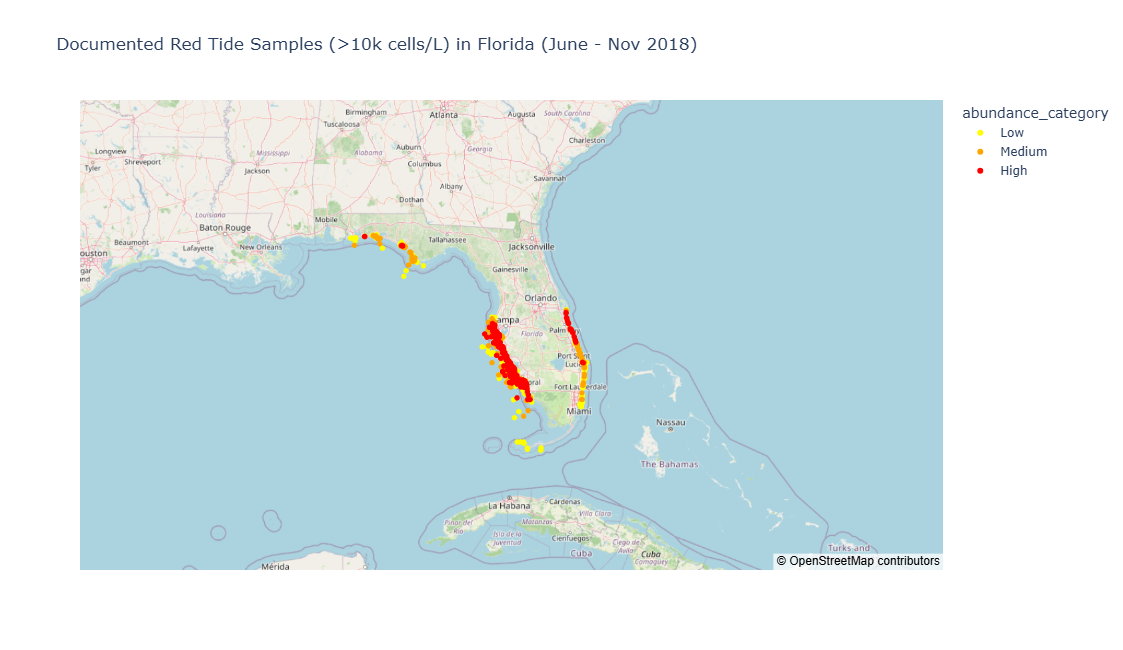

In [12]:
fig_static = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    hover_name="location",
    hover_data=["sample_date", "karenia_brevis_cells_per_liter"],
    category_orders={"abundance_category": abundance_order},
    color_discrete_sequence=["yellow", "orange", "red"],
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    height=650,
    title="Documented Red Tide Samples (>10k cells/L) in Florida (June - Nov 2018)"
)
fig_static.show()

**What spatial pattern is visible in the static map?**

Your answer: The overwhelming majority of elevated cell concentrations occur along the Southwest coast of Florida, with scattered elevated samples appearing up the Panhandle and along the eastern Atlantic coast.

**What important temporal information is difficult to recover from the static map?**

Your answer: Because all six months of data are plotted at once, it is impossible to see when the bloom reached specific regions or if areas recovered while others worsened.

## 13. Animate the documented sample locations

Re-create the spatial figure with `animation_frame="month_label"`. Add the chronological `month_order` to `category_orders` so the slider follows June through November.

Keep the map center, zoom, height, category order, and colors fixed. This makes changes among frames easier to interpret as changes in the observations rather than changes in the display.

In [13]:
fig_anim = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    hover_name="location",
    hover_data=["sample_date", "karenia_brevis_cells_per_liter"],
    category_orders={
        "abundance_category": abundance_order,
        "month_label": month_order
    },
    color_discrete_sequence=["yellow", "orange", "red"],
    animation_frame="month_label",
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    height=650,
    title="Progression of Florida Red Tide (>10k cells/L) by Month"
)
fig_anim.show()

**How did the documented bloom's geographic pattern change from June through November?**

Your answer: It originated primarily in Southwest Florida during the summer. As the months progressed toward October and November, high concentrations migrated northward into the Panhandle and swept around the tip of Florida to appear on the Atlantic coast.

**Which figure makes the timing of geographic expansion easiest to see?**

Your answer: The animated map. By using the slider, the exact geographic expansion across time is immediately obvious.

# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from both the time-series plot and the animated map.**

Your answer: From June through November 2018, the Florida red tide bloom exhibited distinct changes in both concentration and geographic footprint. The time-series plot shows that the percentage of samples reaching dangerous bloom concentrations did not grow linearly; instead, it peaked in late summer (August), dropped in the early fall, and experienced a secondary spike in November. Despite this fluctuation in concentration percentage, the animated map demonstrates continuous geographic expansion. The bloom originated heavily in Southwest Florida during the summer, but by October, it had been carried by currents to significantly impact the Panhandle and the Atlantic East Coast.

**Why does the animation show documented sample locations rather than the complete geographic boundary of the bloom?**

Your answer: The points only represent places where researchers physically traveled to collect a jar of water. A bloom is a fluid, continuous event; there are likely massive stretches of infected water between these plotted points that simply weren't sampled.

**Why should the monthly percentages not be interpreted as the percentage of all Florida coastal water affected by red tide?**

Your answer: This dataset suffers from severe sampling bias. Researchers conduct "event-response sampling," meaning they actively seek out water where a bloom is already suspected. Because they aren't sampling unaffected water at the same rate, calculating a percentage dramatically overrepresents the actual volume of Florida's total coastal water that is affected.

## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: I utilized an AI tool to help structure the Plotly map syntax and verify my Pandas aggregations, particularly for generating the percent_bloom metric correctly. I reviewed the generated code against Plotly Express documentation to ensure the map projections and colors aligned with the assignment requirements.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give every figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Distinguish sample locations from the complete extent of the bloom.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.